In [19]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer

In [3]:
df=pd.read_csv('Bengaluru_House_Data.csv')

In [4]:
df.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


In [5]:
df.dropna(subset=['location'], inplace=True)

In [6]:
df.drop('society', axis=1, inplace=True)

In [7]:
df.shape

(13319, 8)

In [8]:
df.drop_duplicates(inplace=True)

In [9]:
df.isna().sum()

area_type         0
availability      0
location          0
size             16
total_sqft        0
bath             73
balcony         605
price             0
dtype: int64

In [10]:
df.shape

(12751, 8)

In [11]:
df.isna().sum()

area_type         0
availability      0
location          0
size             16
total_sqft        0
bath             73
balcony         605
price             0
dtype: int64

In [20]:
imputer_soc=SimpleImputer(strategy='most_frequent')
df[["balcony"]]=imputer_soc.fit_transform(df[['balcony']])

In [21]:
df['bath'].fillna(df['bath'].median(), inplace=True)

C:\Users\sathi\AppData\Local\Temp\ipykernel_18316\3321556508.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['bath'].fillna(df['bath'].median(), inplace=True)


In [22]:
df.isna().sum()

area_type        0
availability     0
location         0
size            16
total_sqft       0
bath             0
balcony          0
price            0
dtype: int64

In [23]:
df = df.dropna(subset=['size'])

In [24]:
bhk = []

for i in df['size']:
    bhk.append(int(i.split(' ')[0]))

df['bhk'] = bhk

C:\Users\sathi\AppData\Local\Temp\ipykernel_18316\2760433960.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['bhk'] = bhk


In [25]:
df.rename(columns={'size':'bhk'}, inplace=True)
df = df.loc[:, ~df.columns.duplicated(keep='last')]

C:\Users\sathi\AppData\Local\Temp\ipykernel_18316\1974646082.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.rename(columns={'size':'bhk'}, inplace=True)


In [26]:
df.describe()

,bath,balcony,price,bhk
count,12735.000000,12735.000000,12735.000000,12735.000000
mean,2.707185,1.601806,114.509397,2.819395
std,1.357176,0.808883,151.697785,1.313346
min,1.000000,0.000000,8.000000,1.000000
25%,2.000000,1.000000,50.000000,2.000000
50%,2.000000,2.000000,73.000000,3.000000
75%,3.000000,2.000000,122.000000,3.000000
max,40.000000,3.000000,3600.000000,43.000000


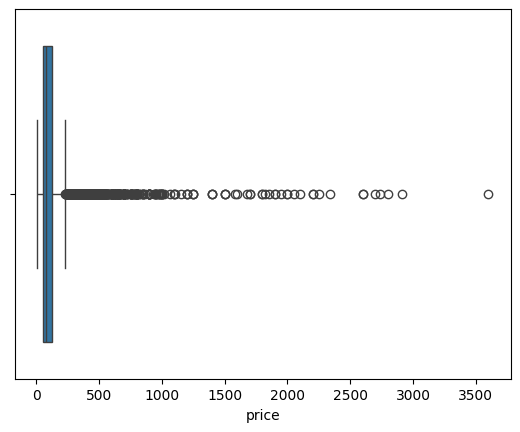

In [27]:
sns.boxplot(x=df['price'])
plt.show()

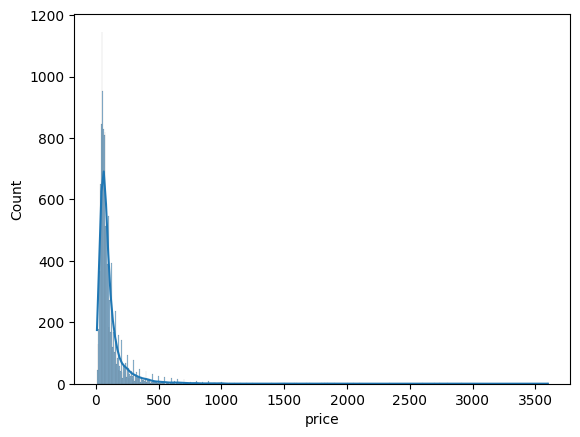

In [28]:
sns.histplot(df['price'], kde=True)
plt.show()

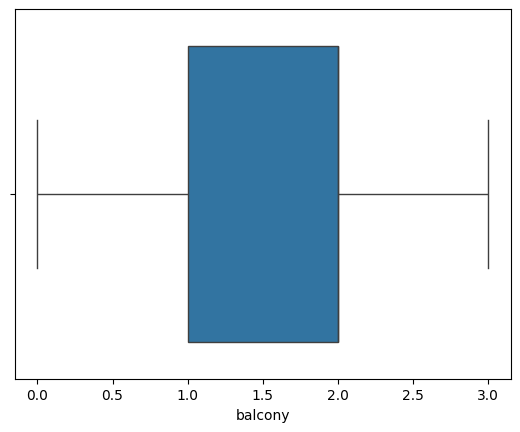

In [29]:
sns.boxplot(x=df['balcony'])
plt.show()

In [30]:
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

lower_limit,upper_limit



(np.float64(-58.0), np.float64(230.0))

In [60]:
X = df[['bhk','total_sqft','bath','balcony']]
y = df['price']

In [57]:

df['total_sqft'] = pd.to_numeric(df['total_sqft'], errors='coerce')
df.dropna(subset=['total_sqft'], inplace=True)

In [61]:
df['total_sqft'].dtype

dtype('float64')

In [64]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [65]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [55]:
X_train.dtypes

bhk             int64
total_sqft     object
bath          float64
balcony       float64
dtype: object

In [66]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [67]:
y_pred = model.predict(X_test)

In [69]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)

print("R2 Score:", r2)

R2 Score: 0.4538300092607924


In [70]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, y_pred)

print("MAE:", mae)

MAE: 47.13891820129131


In [71]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test, y_pred)

print("MSE:", mse)

MSE: 12613.908190450848


In [73]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=42)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)



In [74]:
print(r2_score(y_test, y_pred_rf))

0.41954535067662535
